In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import shap
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load Data
df = pd.read_csv("Telco.csv")

# 3. Clean Data
df = df[df["TotalCharges"].str.strip() != ""]
df["TotalCharges"] = df["TotalCharges"].astype(float)
df.drop("customerID", axis=1, inplace=True)

# 4. Encode Categorical Features
label_enc = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = label_enc.fit_transform(df[col])

In [3]:
# 5. Split Features & Target
X = df.drop("Churn", axis=1)
y = df["Churn"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [4]:
# Model with hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
model = grid_search.best_estimator_

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407


Confusion Matrix:
 [[926 107]
 [187 187]]


  0%|          | 0/20 [00:00<?, ?it/s]

X_sample shape: (20, 19)
SHAP values shape (class 1): (19, 2)


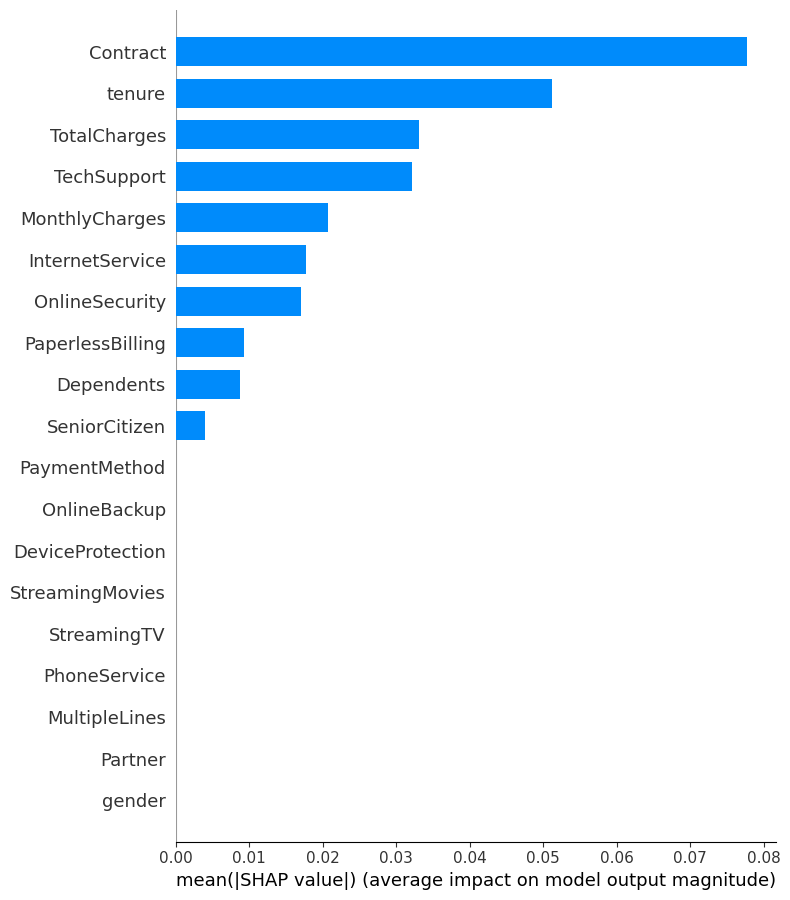

In [5]:
y_pred = model.predict(X_test)
print("Best Parameters:", grid_search.best_params_)
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

X_sample = X_test.sample(20, random_state=42)
X_background = shap.sample(X_train, 100, random_state=42)

# Use KernelExplainer with predict_proba for classification
explainer = shap.KernelExplainer(model.predict_proba, X_background)
shap_values = explainer.shap_values(X_sample)

# Ensure SHAP values match feature shape
print("X_sample shape:", X_sample.shape)
print("SHAP values shape (class 1):", np.array(shap_values[1]).shape)

# Convert X_sample to DataFrame to match feature shape exactly
X_sample_df = pd.DataFrame(X_sample, columns=X.columns)

# Plot (class 1 = Churn)
shap.summary_plot(np.array(shap_values[1]).T, X_sample_df, plot_type="bar")

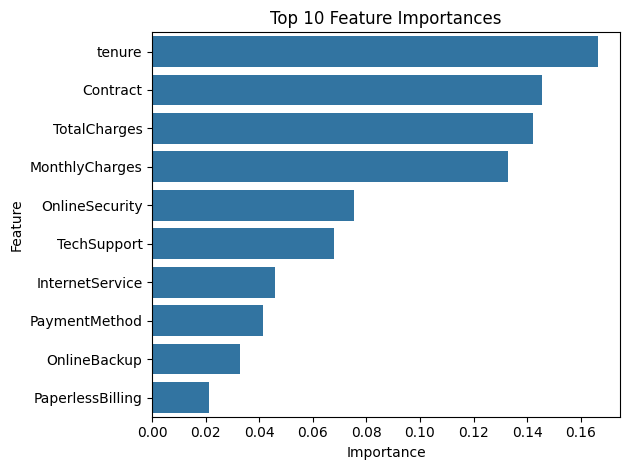

In [6]:
importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)
sns.barplot(x="Importance", y="Feature", data=importances.head(10))
plt.title("Top 10 Feature Importances")
plt.tight_layout()
plt.show()

In [7]:
# Save the trained model to a .pkl file for use in Streamlit
import joblib

# Use the best model from tuning
model_filename = "churn_model_rf.pkl"
joblib.dump(model, model_filename)

model_filename

'churn_model_rf.pkl'

In [8]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "feature_columns.pkl")

['feature_columns.pkl']

In [9]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import FunctionTransformer

# Define a top-level function (not a lambda)
def identity_transform(X):
    return X

dummy_preprocessor = FunctionTransformer(identity_transform)

pipeline = Pipeline([
    ("preprocessor", dummy_preprocessor),
    ("model", model)
])

# Save the pipeline instead of just model
joblib.dump(pipeline, "churn_pipeline.pkl")

['churn_pipeline.pkl']